In [3]:
import math
import numpy as np
import pandas as pd

In [18]:
df = pd.read_csv("listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2992450,Luxury 2 bedroom apartment,4621559,Kenneth,NaN,THIRD WARD,42.65789,-73.75370,Entire home/apt,70.0,28,9,2022-08-17,0.07,1,70,0,NaN
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,Terra,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,100.0,2,308,2025-03-29,2.34,4,335,6,NaN
2,5651579,Large studio apt by Capital Center & ESP@,29288920,Gregg,NaN,SECOND WARD,42.64615,-73.75966,Entire home/apt,75.0,2,371,2025-02-16,3.02,2,15,24,NaN
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,Terra,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,95.0,2,331,2025-02-09,2.72,4,282,14,NaN
4,9005989,"Studio in The heart of Center SQ, in Albany NY",17766924,Sugey,NaN,SIXTH WARD,42.65559,-73.76506,Entire home/apt,86.0,1,620,2025-05-08,5.76,1,128,29,NaN


In [26]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [27]:
train_df.shape, test_df.shape

((357, 18), (90, 18))

In [28]:
test_df.dropna(subset=['price'], inplace=True)
train_df.dropna(subset=['price'], inplace=True)

In [30]:
train_df.shape,test_df.shape

((333, 18), (82, 18))

Note: you may need to restart the kernel to use updated packages.


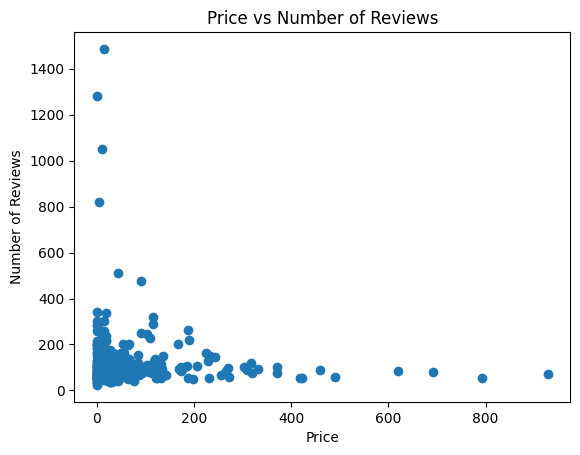

In [36]:
%pip install matplotlib

import matplotlib.pyplot as plt

plt.scatter(train_df['number_of_reviews'],train_df['price'])
plt.xlabel('Price')
plt.ylabel('Number of Reviews')
plt.title('Price vs Number of Reviews')
plt.show()

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Select numeric features and target
features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']
X = train_df[features]
y = train_df['price']

# Check feature scales
print(X.describe())

# Standardize features if scales are very different
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit linear regression on standardized features
model = LinearRegression()
model.fit(X_scaled, y)

# To predict on test set:
X_test = test_df[features]
X_test_scaled = scaler.transform(X_test)
predictions = model.predict(X_test_scaled)

       minimum_nights  number_of_reviews  reviews_per_month  \
count      333.000000         333.000000         289.000000   
mean         5.819820          62.786787           2.048824   
std         10.275598         114.205029           2.036303   
min          1.000000           0.000000           0.040000   
25%          1.000000           3.000000           0.490000   
50%          2.000000          20.000000           1.350000   
75%          3.000000          67.000000           3.020000   
max         70.000000         928.000000          11.340000   

       calculated_host_listings_count  availability_365  number_of_reviews_ltm  
count                      333.000000        333.000000             333.000000  
mean                         6.483483        232.633634              16.216216  
std                          6.446527        111.477040              22.381847  
min                          1.000000          0.000000               0.000000  
25%                        

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values